# gigapath_runpod_modeling (S3 features → RunPod MIL 학습)

`gigapath_runpod.ipynb`에서 임베딩(.pt)을 생성해 S3에 올렸다고 가정하고, RunPod에서 다운로드→MIL 학습까지 이어서 실행하는 노트북입니다. Attention MIL / CLAM 스타일 / TransMIL을 모두 지원하는 단일 스크립트를 원격에 작성·실행합니다.


## 0. 기본 설정
- RunPod SSH/rsync 접속 정보와 경로(기존 노트북과 동일 기본값)
- S3 접두사(`S3_PREFIX`)와 AWS 프로파일/리전
- 라벨 parquet 업로드 후 manifest.csv를 원격에서 생성(split 포함)
- 토글: `RUN_REMOTE_SETUP`, `RUN_S3_SYNC`, `WRITE_TRAINER`, `RUN_TRAINING`


In [24]:
import os, shlex, subprocess, time, json
from pathlib import Path
# SSH 대상 및 키 (기존 runpod 설정 재사용)
SSH_HOST_GATEWAY = 'vvy5ke98vgtmim-64411852@ssh.runpod.io'
SSH_HOST_DIRECT = 'root@69.30.85.100'
SSH_PORT_DIRECT = 22027
SSH_KEY = '~/.ssh/runpod_peter'
USE_DIRECT_FOR_SSH = True
USE_DIRECT_FOR_RSYNC = True
SSH_EXTRA_OPTS = ''

# RunPod 경로
REMOTE_BASE = '/workspace/data'
REMOTE_RAW = f"{REMOTE_BASE}/raw"
REMOTE_WORK = f"{REMOTE_BASE}/work"
REMOTE_FEATURE_DIR = f"{REMOTE_WORK}/features"
REMOTE_CHECKPOINT = f"{REMOTE_WORK}/checkpoints"
REMOTE_LOG = f"{REMOTE_BASE}/logs"
REMOTE_MANIFEST = f"{REMOTE_WORK}/manifest.csv"
REMOTE_TRAIN_SCRIPT = f"{REMOTE_WORK}/train_mil.py"
REMOTE_HEATMAP = f"{REMOTE_WORK}/heatmap"
REMOTE_VENV = '~/venv_gigapath'

# S3 설정 (임베딩 .pt 저장 위치)
S3_PREFIX = 's3://gc-pathology/gv-level1-embedding-metadata/'  # 접두사만 작성
AWS_PROFILE = None  # 예: 'default' 또는 None
AWS_REGION = 'ap-northeast-2'
AWS_ENDPOINT = None  # 커스텀 엔드포인트 있으면 입력
RUN_S3_SYNC = True

# 라벨/manifest 설정 (필요 시 경로 수정)
LABEL_PARQUET_LOCAL = Path('/Users/curv/Repos/GC-Pathology/PoC/v1/mammary_adenoma_vs_adenocarcinoma_only(2023).parquet')
LABEL_MAP = {"adenoma": 0, "adenocarcinoma": 1, "mammary_adenoma": 0, "mammary_adenocarcinoma": 1}
VAL_RATIO = 0.15
TEST_RATIO = 0.10
RANDOM_SEED = 42
MAX_TILES_PER_SLIDE = 8000  # 메모리 안전용 샘플링 상한 (None이면 전체)

# 학습/스크립트 토글
RUN_REMOTE_SETUP = True
WRITE_TRAINER = True
RUN_TRAINING = True

print('SSH_HOST_DIRECT=', SSH_HOST_DIRECT, 'port', SSH_PORT_DIRECT)
print('REMOTE_FEATURE_DIR=', REMOTE_FEATURE_DIR)
print('S3_PREFIX=', S3_PREFIX)
print('워크플로우: 1) 원격 디렉터리 준비 → 2) venv 설치 → 3) S3 동기화 → 4) manifest 생성 → 5) MIL 학습/평가')


SSH_HOST_DIRECT= root@69.30.85.100 port 22027
REMOTE_FEATURE_DIR= /workspace/data/work/features
S3_PREFIX= s3://gc-pathology/gv-level1-embedding-metadata/
워크플로우: 1) 원격 디렉터리 준비 → 2) venv 설치 → 3) S3 동기화 → 4) manifest 생성 → 5) MIL 학습/평가


## 1. 로컬→RunPod 유틸리티 (SSH/rsync)
- `run_local`, `run_ssh`, `rsync_upload/download`
- 원격 경로 생성/상태 확인 헬퍼 포함


In [25]:

def run_local(cmd, check=True):
    print(f"[local] $ {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if check and result.returncode != 0:
        msg = result.stderr.strip() or result.stdout.strip()
        raise RuntimeError(f"Local command failed ({result.returncode}): {cmd}{msg}")
    return result.returncode


def _ssh_parts(host, port=None):
    parts = ['ssh']
    if SSH_KEY:
        parts += ['-i', SSH_KEY]
    if SSH_EXTRA_OPTS:
        parts += shlex.split(SSH_EXTRA_OPTS)
    if port:
        parts += ['-p', str(port)]
    parts += [host]
    return parts


def run_ssh(cmd, check=True, use_direct=None):
    if use_direct is None:
        use_direct = USE_DIRECT_FOR_SSH
    parts = _ssh_parts(
        SSH_HOST_DIRECT if use_direct else SSH_HOST_GATEWAY,
        SSH_PORT_DIRECT if use_direct else None,
    )
    ssh_cmd = ' '.join(shlex.quote(p) for p in parts + [cmd])
    print(f"[ssh] $ {cmd}")
    result = subprocess.run(ssh_cmd, shell=True, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if check and result.returncode != 0:
        msg = result.stderr.strip() or result.stdout.strip()
        raise RuntimeError(f"SSH command failed ({result.returncode}): {cmd}{msg}")
    return result.returncode


def _rsync_ssh_opt(use_direct=True):
    key = Path(SSH_KEY).expanduser() if SSH_KEY else None
    parts = ['ssh']
    if key:
        parts += ['-i', str(key)]
    if SSH_EXTRA_OPTS:
        parts += shlex.split(SSH_EXTRA_OPTS)
    if use_direct:
        parts += ['-p', str(SSH_PORT_DIRECT)]
    return ' '.join(parts)


def rsync_upload(local_path: Path, remote_dir: str):
    use_direct = USE_DIRECT_FOR_RSYNC
    ssh_opt = _rsync_ssh_opt(use_direct)
    remote_host = SSH_HOST_DIRECT if use_direct else SSH_HOST_GATEWAY
    remote_target = f"{remote_host}:{remote_dir.rstrip('/')}/"
    cmd = (
        f"rsync -avh --no-perms --no-owner --no-group --partial --progress -e {shlex.quote(ssh_opt)} "
        f"{shlex.quote(str(local_path))} {remote_target}"
    )
    run_local(cmd)


def rsync_download(remote_path: str, local_dir: Path):
    use_direct = USE_DIRECT_FOR_RSYNC
    ssh_opt = _rsync_ssh_opt(use_direct)
    remote_host = SSH_HOST_DIRECT if use_direct else SSH_HOST_GATEWAY
    local_dir.mkdir(parents=True, exist_ok=True)
    remote_src = f"{remote_host}:{remote_path}"
    cmd = (
        f"rsync -avh --no-perms --no-owner --no-group --partial --progress -e {shlex.quote(ssh_opt)} "
        f"{remote_src} {shlex.quote(str(local_dir))}/"
    )
    run_local(cmd)


def ensure_remote_dirs():
    print('[단계] 원격 디렉터리 및 GPU 상태 확인 중...')
    run_ssh(f"mkdir -p {REMOTE_FEATURE_DIR} {REMOTE_CHECKPOINT} {REMOTE_LOG} {REMOTE_WORK} {REMOTE_HEATMAP} {REMOTE_RAW}")
    run_ssh("echo 'SSH OK on $(hostname)' && nvidia-smi || true", check=False)
    run_ssh("df -h . || true", check=False)
    print('[완료] 원격 디렉터리 준비 완료')


ensure_remote_dirs()


[단계] 원격 디렉터리 및 GPU 상태 확인 중...
[ssh] $ mkdir -p /workspace/data/work/features /workspace/data/work/checkpoints /workspace/data/logs /workspace/data/work /workspace/data/work/heatmap /workspace/data/raw
[ssh] $ echo 'SSH OK on $(hostname)' && nvidia-smi || true
SSH OK on $(hostname)
Thu Dec  4 03:20:17 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  

## 2. 원격 의존성 설치 (venv)
- torch는 RunPod 기본 CUDA 이미지에 있다고 가정, 부족 시 버전 명시 가능
- 추가 패키지: scikit-learn, torchmetrics, einops, awscli 등


In [3]:

REMOTE_PY_PKGS = [
    'pip', 'setuptools', 'wheel',
    'pandas', 'numpy', 'scikit-learn', 'tqdm', 'torchmetrics', 'einops',
    'pyyaml', 'awscli', 'pyarrow',
    'timm', 'openslide-python', 'huggingface_hub', 'matplotlib', 'scikit-image', 'scipy', 'pillow'
]

RUN_REMOTE_SETUP = bool(RUN_REMOTE_SETUP)


def install_remote_deps(pkgs=None, venv_path=REMOTE_VENV):
    pkgs = pkgs or REMOTE_PY_PKGS
    pkg_str = ' '.join(pkgs)
    cmd = (
        f"python3 -m venv {venv_path} && "
        f"{venv_path}/bin/pip install --upgrade pip setuptools wheel && "
        f"{venv_path}/bin/pip install {pkg_str}"
    )
    print('[단계] 가상환경 설치/업데이트 시작 ->', venv_path)
    print('       패키지:', pkg_str)
    run_ssh(cmd)
    print('[완료] 가상환경 패키지 설치 완료')


if RUN_REMOTE_SETUP:
    install_remote_deps()
else:
    print('가상환경 설치 건너뜀 (RUN_REMOTE_SETUP=False)')


[단계] 가상환경 설치/업데이트 시작 -> ~/venv_gigapath
       패키지: pip setuptools wheel pandas numpy scikit-learn tqdm torchmetrics einops pyyaml awscli pyarrow timm openslide-python huggingface_hub matplotlib scikit-image scipy pillow
[ssh] $ python3 -m venv ~/venv_gigapath && ~/venv_gigapath/bin/pip install --upgrade pip setuptools wheel && ~/venv_gigapath/bin/pip install pip setuptools wheel pandas numpy scikit-learn tqdm torchmetrics einops pyyaml awscli pyarrow timm openslide-python huggingface_hub matplotlib scikit-image scipy pillow

[완료] 가상환경 패키지 설치 완료


## 3. S3 → RunPod feature 동기화
- `RUN_S3_SYNC=True`로 토글 후 실행
- AWS 자격 증명은 RunPod에 미리 export하거나 `AWS_PROFILE`/`AWS_*` 값으로 전달


In [4]:

RUN_S3_SYNC = bool(RUN_S3_SYNC)


def sync_s3_features():
    env_exports = []
    if AWS_PROFILE:
        env_exports.append(f"AWS_PROFILE={AWS_PROFILE}")
    if AWS_REGION:
        env_exports.append(f"AWS_DEFAULT_REGION={AWS_REGION}")
    if AWS_ENDPOINT:
        env_exports.append(f"AWS_ENDPOINT_URL={AWS_ENDPOINT}")
    env_prefix = ' '.join(env_exports) + ' ' if env_exports else ''
    cmd = f"{env_prefix}{REMOTE_VENV}/bin/aws s3 sync {S3_PREFIX} {REMOTE_FEATURE_DIR}/"
    print(f"[단계] S3 임베딩 동기화 시작: {S3_PREFIX} -> {REMOTE_FEATURE_DIR}")
    run_ssh(cmd)
    stat_cmd = (
        f"echo '[remote] 동기화 후 PT 파일 개수:' && find {REMOTE_FEATURE_DIR} -maxdepth 1 -name '*.pt' | wc -l && "
        f"du -sh {REMOTE_FEATURE_DIR} || true; "
        f"ls -1 {REMOTE_FEATURE_DIR} | head || true; "
        f"ls -1 {REMOTE_FEATURE_DIR} | tail || true"
    )
    run_ssh(stat_cmd, check=False)
    print('[완료] S3 동기화 완료')


if RUN_S3_SYNC:
    sync_s3_features()
else:
    print('S3 sync skipped (RUN_S3_SYNC=False)')


[단계] S3 임베딩 동기화 시작: s3://gc-pathology/gv-level1-embedding-metadata/ -> /workspace/data/work/features
[ssh] $ AWS_DEFAULT_REGION=ap-northeast-2 ~/venv_gigapath/bin/aws s3 sync s3://gc-pathology/gv-level1-embedding-metadata/ /workspace/data/work/features/
[ssh] $ echo '[remote] 동기화 후 PT 파일 개수:' && find /workspace/data/work/features -maxdepth 1 -name '*.pt' | wc -l && du -sh /workspace/data/work/features || true; ls -1 /workspace/data/work/features | head || true; ls -1 /workspace/data/work/features | tail || true
[remote] 동기화 후 PT 파일 개수:
1167
63M	/workspace/data/work/features
S23-00019#1###3.pt
S23-00021#1###7.pt
S23-00026#1###9.pt
S23-00027#1###0.pt
S23-00028#1###1.pt
S23-00035#1###4.pt
S23-00039#1###8.pt
S23-00054#1###9.pt
S23-00059#1###5.pt
S23-00060#1###6.pt
S23-09292#1###7.pt
S23-09296#1###0.pt
S23-09302#1###5.pt
S23-09305#1###8.pt
S23-09314#1###6.pt
S23-09315#1###8.pt
S23-09317#1###8.pt
S23-09321#1###2.pt
S23-09322#1###3.pt
S23-09323#1###4.pt

[완료] S3 동기화 완료


## 4. 라벨 parquet 업로드 및 manifest 생성
- 로컬 parquet(`LABEL_PARQUET_LOCAL`)을 rsync 업로드 후 원격에서 manifest.csv를 만듭니다.
- 라벨 컬럼 소문자 매핑(`LABEL_MAP`)을 사용, `FILE_NAME`/`INSP_RQST_NO`/`FOLDER` 중 일치하는 키로 매칭.
- `VAL_RATIO`/`TEST_RATIO`로 split 컬럼 추가.


In [14]:

from string import Template

manifest_template = Template(r'''
$REMOTE_VENV/bin/python - <<'PY'
import json, random
from collections import Counter
from pathlib import Path
import subprocess

try:
    import pandas as pd
except ImportError:
    print('[단계] pandas/pyarrow 미설치 → 설치 시도')
    subprocess.check_call(['$REMOTE_VENV/bin/pip', 'install', '-q', 'pandas', 'pyarrow'])
    import pandas as pd

print('[단계] 라벨 parquet와 임베딩을 이용해 manifest 생성')

label_path = Path('$REMOTE_WORK') / '$LABEL_NAME'
features_dir = Path('$REMOTE_FEATURE_DIR')
manifest_path = Path('$REMOTE_MANIFEST')
label_map = $LABEL_MAP_JSON
val_ratio = $VAL_RATIO
test_ratio = $TEST_RATIO
seed = $RANDOM_SEED

print('  label parquet:', label_path)
print('  feature dir:', features_dir)
print('  split 비율 -> val', val_ratio, 'test', test_ratio)

if not label_path.exists():
    raise SystemExit(f'label parquet missing on remote: {label_path}')
if not features_dir.exists():
    raise SystemExit(f'feature dir missing: {features_dir}')

df = pd.read_parquet(label_path)

label_col = None
for cand in ['label', 'LABEL']:
    if cand in df.columns:
        label_col = cand
        break
if label_col is None:
    raise SystemExit('label column not found; expected "label"')

print('라벨 분포 (parquet):', df[label_col].value_counts().to_dict())


def norm_label(x):
    key = str(x).lower().strip()
    return label_map.get(key)


def candidate_ids(row):
    ids = []
    file_names = str(row.get('FILE_NAME', '')).split('|')
    for fn in file_names:
        fn = fn.strip()
        if fn:
            ids.append(Path(fn).stem)
    slide_id = row.get('INSP_RQST_NO', row.get('INSP_RQST_NUM', row.get('FOLDER', '')))
    slide_id = str(slide_id).strip()
    if slide_id:
        ids.append(slide_id)
    return [i for i in ids if i]

label_index = {}
for _, row in df.iterrows():
    lbl = norm_label(row[label_col])
    if lbl is None:
        continue
    for cid in candidate_ids(row):
        label_index[cid] = int(lbl)

print('라벨 인덱스 매핑 개수:', len(label_index))

feature_files = sorted(features_dir.glob('*.pt'))
print('다운로드된 feature 파일 개수:', len(feature_files))

records = []
unmatched = []
for pt in feature_files:
    slide_id = pt.stem.replace('_gigapath', '')
    lbl = label_index.get(slide_id)
    if lbl is None:
        unmatched.append(slide_id)
        continue
    records.append({'slide_id': slide_id, 'label': lbl, 'pt_path': str(pt.resolve())})

if not records:
    raise SystemExit('No features matched labels; check naming conventions.')

random.seed(seed)
random.shuffle(records)

val_n = int(len(records) * val_ratio)
test_n = int(len(records) * test_ratio)
for i, rec in enumerate(records):
    if i < val_n:
        rec['split'] = 'val'
    elif i < val_n + test_n:
        rec['split'] = 'test'
    else:
        rec['split'] = 'train'

man_df = pd.DataFrame.from_records(records)
print('매칭된 라벨 분포:', dict(Counter(man_df['label'])))
print('split 개수:', man_df['split'].value_counts().to_dict())
man_df.to_csv(manifest_path, index=False)
print('manifest 저장 완료:', manifest_path)
if unmatched:
    print('라벨 매칭 실패 feature (앞 10개):', unmatched[:10])
PY
''')


def upload_labels():
    if not LABEL_PARQUET_LOCAL.exists():
        raise FileNotFoundError(f'label parquet not found: {LABEL_PARQUET_LOCAL}')
    print(f"[단계] 라벨 parquet 업로드: {LABEL_PARQUET_LOCAL.name} -> {REMOTE_WORK}")
    rsync_upload(LABEL_PARQUET_LOCAL, REMOTE_WORK)
    print('[완료] 라벨 업로드 완료')


def build_remote_manifest():
    print('[단계] 원격 manifest 생성 시작')
    script = manifest_template.substitute(
        REMOTE_WORK=REMOTE_WORK,
        LABEL_NAME=LABEL_PARQUET_LOCAL.name,
        REMOTE_FEATURE_DIR=REMOTE_FEATURE_DIR,
        REMOTE_MANIFEST=REMOTE_MANIFEST,
        LABEL_MAP_JSON=json.dumps({k: int(v) for k, v in LABEL_MAP.items()}),
        VAL_RATIO=VAL_RATIO,
        TEST_RATIO=TEST_RATIO,
        RANDOM_SEED=RANDOM_SEED,
        REMOTE_VENV=REMOTE_VENV,
    )
    run_ssh(script)
    print('[완료] 원격 manifest 생성 완료')


upload_labels()
build_remote_manifest()


[단계] 라벨 parquet 업로드: mammary_adenoma_vs_adenocarcinoma_only(2023).parquet -> /workspace/data/work
[local] $ rsync -avh --no-perms --no-owner --no-group --partial --progress -e 'ssh -i /Users/curv/.ssh/runpod_peter -p 22027' '/Users/curv/Repos/GC-Pathology/PoC/v1/mammary_adenoma_vs_adenocarcinoma_only(2023).parquet' root@69.30.85.100:/workspace/data/work/
Transfer starting: 1 files

sent 90 bytes  received 20 bytes  264 bytes/sec
total size is 1969k  speedup is 17901.16

[완료] 라벨 업로드 완료
[단계] 원격 manifest 생성 시작
[ssh] $ 
~/venv_gigapath/bin/python - <<'PY'
import json, random
from collections import Counter
from pathlib import Path
import subprocess

try:
    import pandas as pd
except ImportError:
    print('[단계] pandas/pyarrow 미설치 → 설치 시도')
    subprocess.check_call(['~/venv_gigapath/bin/pip', 'install', '-q', 'pandas', 'pyarrow'])
    import pandas as pd

print('[단계] 라벨 parquet와 임베딩을 이용해 manifest 생성')

label_path = Path('/workspace/data/work') / 'mammary_adenoma_vs_adenocarcinoma_only(20

## 5. 원격 MIL 학습 스크립트 작성 (Attention/CLAM/TransMIL)
- RunPod에 `train_mil.py`를 생성합니다.
- 배치 단위=슬라이드 1개(bag), AMP 지원, pos-weight 자동 계산.
- 입력 manifest: `slide_id,label,pt_path,split` 컬럼.


In [6]:

import textwrap


TRAIN_SCRIPT = r'''
import argparse, json, os, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, confusion_matrix

FEATURE_KEYS = ['features', 'feats', 'embedding', 'embeddings', 'feat']
COORD_KEYS = ['coords', 'coord', 'locs', 'locations']

def load_feats_coords(data):
    import re
    feature_keys = ['features', 'feats', 'embedding', 'embeddings', 'feat', 'last_layer_embed']
    feats = None
    for k in feature_keys:
        if k in data:
            feats = data[k]
            break
    if feats is None:
        layer_keys = [k for k in data.keys() if re.match(r'^layer_\d+_embed$', k)]
        if layer_keys:
            best = sorted(layer_keys, key=lambda x: int(re.findall(r'\d+', x)[0]))[-1]
            feats = data[best]
    coords = None
    for k in ['coords', 'coord', 'locs', 'locations']:
        if k in data:
            coords = data[k]
            break
    if feats is None:
        raise KeyError(f"feature key not found in pt; available keys={list(data.keys())}")
    return feats, coords

from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from einops import rearrange

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {}
    try:
        metrics['auc'] = float(roc_auc_score(y_true, y_prob))
    except Exception:
        metrics['auc'] = float('nan')
    try:
        metrics['ap'] = float(average_precision_score(y_true, y_prob))
    except Exception:
        metrics['ap'] = float('nan')
    metrics['f1'] = float(f1_score(y_true, y_pred)) if len(y_true) else float('nan')
    metrics['acc'] = float(accuracy_score(y_true, y_pred)) if len(y_true) else float('nan')
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    except Exception:
        tn = fp = fn = tp = float('nan')
    metrics['confusion'] = {'tn': float(tn), 'fp': float(fp), 'fn': float(fn), 'tp': float(tp)}
    return metrics

class SlideBagDataset(Dataset):
    def __init__(self, manifest_path: Path, split: str, max_tiles=None, shuffle_tiles=False):
        df = pd.read_csv(manifest_path)
        self.df = df[df['split'] == split].reset_index(drop=True)
        self.max_tiles = max_tiles
        self.shuffle_tiles = shuffle_tiles

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data = torch.load(row['pt_path'], map_location='cpu')
        feats, coords = load_feats_coords(data)
        if isinstance(coords, np.ndarray):
            coords = torch.from_numpy(coords)
        feats = feats.float()
        if coords is not None:
            coords = coords.int()
        if self.shuffle_tiles:
            perm = torch.randperm(len(feats))
            feats = feats[perm]
            if coords is not None:
                coords = coords[perm]
        if self.max_tiles and len(feats) > self.max_tiles:
            idxs = torch.randperm(len(feats))[: self.max_tiles]
            feats = feats[idxs]
            if coords is not None:
                coords = coords[idxs]
        label = torch.tensor(float(row['label']), dtype=torch.float32)
        return feats, coords, label, row['slide_id']

def collate_fn(batch):
    feats, coords, labels, slide_ids = zip(*batch)
    labels = torch.tensor(labels, dtype=torch.float32)
    return list(feats), list(coords), labels, list(slide_ids)

class AttentionMIL(nn.Module):
    def __init__(self, in_dim, hidden_dim=256, dropout=0.2, gated=False):
        super().__init__()
        self.gated = gated
        self.input_norm = nn.LayerNorm(in_dim)
        self.dropout = nn.Dropout(dropout)
        self.attn_v = nn.Linear(in_dim, hidden_dim)
        self.attn_u = nn.Linear(in_dim, hidden_dim) if gated else None
        self.attn_out = nn.Linear(hidden_dim, 1)
        self.classifier = nn.Linear(in_dim, 1)

    def forward(self, feats, coords=None):
        x = self.dropout(self.input_norm(feats))
        v = torch.tanh(self.attn_v(x))
        if self.gated:
            u = torch.sigmoid(self.attn_u(x))
            v = v * u
        attn_score = self.attn_out(v).squeeze(-1)
        weight = torch.softmax(attn_score, dim=0)
        pooled = torch.sum(weight.unsqueeze(-1) * x, dim=0)
        logit = self.classifier(pooled).squeeze(0)
        return logit, weight

class TransMIL(nn.Module):
    def __init__(self, in_dim, depth=2, heads=4, ff_dim=512, dropout=0.1, use_pos_enc=False):
        super().__init__()
        self.use_pos_enc = use_pos_enc
        self.input_norm = nn.LayerNorm(in_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=in_dim, nhead=heads, dim_feedforward=ff_dim, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.cls_token = nn.Parameter(torch.randn(1, 1, in_dim) * 0.02)
        self.cls_bias = nn.Parameter(torch.zeros(1, 1, in_dim))
        self.pos_mlp = nn.Sequential(nn.LayerNorm(2), nn.Linear(2, in_dim)) if use_pos_enc else None
        self.classifier = nn.Linear(in_dim, 1)

    def forward(self, feats, coords=None):
        feats = self.input_norm(feats)
        x = feats.unsqueeze(0)
        if self.use_pos_enc and coords is not None and coords.shape[0] > 1:
            pos = coords.float()
            pos_std = pos.std(0, keepdim=True)
            pos_std = torch.where(pos_std > 1e-6, pos_std, torch.ones_like(pos_std))
            pos = (pos - pos.mean(0, keepdim=True)) / pos_std
            x = x + self.pos_mlp(pos).unsqueeze(0)
        cls = self.cls_token + self.cls_bias
        tokens = torch.cat([cls, x], dim=1)
        out = self.encoder(tokens)
        cls_out = out[:, 0]
        logit = self.classifier(cls_out).squeeze(1)
        attn_score = torch.matmul(out[:, 1:], cls_out.unsqueeze(-1)).squeeze(-1)
        weight = torch.softmax(attn_score, dim=-1)
        return logit.squeeze(0), weight.squeeze(0)

def infer_in_dim(manifest_path: Path):
    df = pd.read_csv(manifest_path)
    if df.empty:
        raise RuntimeError('manifest is empty')
    sample_pt = Path(df.iloc[0]['pt_path'])
    data = torch.load(sample_pt, map_location='cpu')
    feats, _ = load_feats_coords(data)
    return int(feats.shape[1])

def make_loaders(manifest_path, max_tiles, num_workers):
    train_ds = SlideBagDataset(manifest_path, 'train', max_tiles=max_tiles, shuffle_tiles=True)
    val_ds = SlideBagDataset(manifest_path, 'val', max_tiles=max_tiles, shuffle_tiles=False)
    test_ds = SlideBagDataset(manifest_path, 'test', max_tiles=max_tiles, shuffle_tiles=False)

    def _loader(ds, shuffle):
        if len(ds) == 0:
            return None
        return DataLoader(ds, batch_size=1, shuffle=shuffle, num_workers=num_workers, collate_fn=collate_fn)

    return _loader(train_ds, True), _loader(val_ds, False), _loader(test_ds, False), train_ds, val_ds, test_ds

def find_best_threshold(y_true, y_prob, grid=None):
    grid = grid or np.arange(0.3, 0.71, 0.05)
    best_t, best_f1 = 0.5, -1
    for t in grid:
        pred = (np.array(y_prob) >= t).astype(int)
        f1 = f1_score(y_true, pred) if len(y_true) else float('nan')
        if np.isnan(f1):
            continue
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1

def run_split(model, loader, device, threshold):
    if loader is None:
        return {'auc': float('nan'), 'ap': float('nan'), 'f1': float('nan'), 'acc': float('nan'), 'confusion': {}}, [] , [], []
    model.eval()
    y_true, y_prob, rows = [], [], []
    with torch.inference_mode():
        for feats, coords, labels, slide_ids in loader:
            feats = feats[0].to(device)
            coords = coords[0].to(device) if coords[0] is not None else None
            labels = labels.to(device)
            logit, attn = model(feats, coords)
            prob = torch.sigmoid(logit).item()
            y_true.append(float(labels.item()))
            y_prob.append(prob)
            rows.append({'slide_id': slide_ids[0], 'prob': prob, 'label': float(labels.item())})
    metrics = compute_metrics(y_true, y_prob, threshold=threshold)
    return metrics, rows, y_true, y_prob

def train(args):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    set_seed(args.seed)

    manifest = pd.read_csv(args.manifest)
    split_counts = manifest['split'].value_counts().to_dict()
    label_counts = manifest['label'].value_counts().to_dict()
    print(f"[단계] manifest 로드 ({args.manifest}) -> 총 {len(manifest)} 슬라이드")
    print('       split 분포:', split_counts)
    print('       라벨 분포:', label_counts)

    in_dim = infer_in_dim(args.manifest)
    if args.model == 'transmil':
        model = TransMIL(
            in_dim,
            depth=args.depth,
            heads=args.heads,
            ff_dim=args.ffn_dim,
            dropout=args.dropout,
            use_pos_enc=args.use_pos_enc,
        )
    elif args.model == 'clam':
        model = AttentionMIL(in_dim, hidden_dim=args.hidden_dim, dropout=args.dropout, gated=True)
    else:
        model = AttentionMIL(in_dim, hidden_dim=args.hidden_dim, dropout=args.dropout, gated=False)
    model = model.to(device)

    train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = make_loaders(
        args.manifest, args.max_tiles, args.num_workers
    )
    if train_loader is None:
        raise RuntimeError('train split is empty')

    pos = float((manifest['label'] == 1).sum())
    neg = float((manifest['label'] == 0).sum())
    auto_pw = (neg + 1.0) / (pos + 1.0)
    pos_weight = torch.tensor([args.pos_weight if args.pos_weight > 0 else auto_pw], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(args.epochs, 1))
    scaler = torch.cuda.amp.GradScaler(enabled=args.precision == 'fp16')

    print(f"[단계] 데이터 크기 -> train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}")
    print(f"[단계] {device}에서 {args.epochs} epoch 학습 시작 (precision {args.precision})")

    best_auc = -1.0
    best_path = Path(args.ckpt_dir) / 'best.pt'
    Path(args.ckpt_dir).mkdir(parents=True, exist_ok=True)
    Path(args.logdir).mkdir(parents=True, exist_ok=True)
    no_improve = 0

    history = []
    for epoch in range(1, args.epochs + 1):
        model.train()
        running_loss = 0.0
        optimizer.zero_grad(set_to_none=True)
        pbar = tqdm(train_loader, desc=f'train epoch {epoch}', ncols=100)
        for step, (feats, coords, labels, slide_ids) in enumerate(pbar, 1):
            feats = feats[0].to(device)
            coords = coords[0].to(device) if coords[0] is not None else None
            labels = labels.to(device)
            if args.label_smoothing > 0:
                eps = args.label_smoothing
                labels = labels * (1 - eps) + 0.5 * eps
            with torch.cuda.amp.autocast(enabled=args.precision == 'fp16'):
                logit, attn = model(feats, coords)
                loss = criterion(logit.view_as(labels), labels)
                loss = loss / args.grad_accum
            scaler.scale(loss).backward()
            if step % args.grad_accum == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            running_loss += loss.item()
            pbar.set_postfix({'loss': running_loss / step})
        scheduler.step()

        val_metrics, _, y_true, y_prob = run_split(model, val_loader, device, args.threshold)
        history.append({'epoch': epoch, 'val': val_metrics, 'loss': running_loss / max(1, step)})
        print(f"epoch {epoch}: val_auc={val_metrics['auc']:.4f} f1={val_metrics['f1']:.4f}")

        if val_metrics['auc'] > best_auc:
            best_auc = val_metrics['auc']
            torch.save({'model_state': model.state_dict(), 'config': vars(args), 'val_metrics': val_metrics}, best_path)
            print('=> 최고 성능 갱신, 체크포인트 저장:', best_path)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= args.patience:
                print(f"[조기 종료] {args.patience} epoch 동안 개선 없음 → 중단")
                break

    best = torch.load(best_path, map_location=device)
    model.load_state_dict(best['model_state'])
    val_metrics, val_rows, val_true, val_prob = run_split(model, val_loader, device, args.threshold)
    best_thr, best_f1 = find_best_threshold(val_true, val_prob)
    val_best = compute_metrics(val_true, val_prob, threshold=best_thr)
    test_metrics, test_rows, test_true, test_prob = run_split(model, test_loader, device, best_thr)

    summary = {
        'best_val_auc': best_auc,
        'val': val_metrics,
        'val_best_threshold': best_thr,
        'val_best_metrics': val_best,
        'test': test_metrics,
        'history': history,
    }
    log_path = Path(args.logdir) / 'mil_training.json'
    with open(log_path, 'w') as f:
        json.dump(summary, f, indent=2)
    print('== 최종 성능 ==')
    print('  validation(default thr):', val_metrics)
    print('  validation(best thr):', val_best)
    print('  test (best thr from val):', test_metrics)
    print('best threshold (val f1):', best_thr)
    print('결과 저장:', log_path)
    if test_rows:
        pd.DataFrame(test_rows).to_csv(Path(args.logdir) / 'test_preds.csv', index=False)
    if val_rows:
        pd.DataFrame(val_rows).to_csv(Path(args.logdir) / 'val_preds.csv', index=False)

def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument('--manifest', required=True)
    p.add_argument('--ckpt_dir', default='checkpoints')
    p.add_argument('--logdir', default='logs')
    p.add_argument('--model', choices=['abmil', 'clam', 'transmil'], default='abmil')
    p.add_argument('--hidden_dim', type=int, default=256)
    p.add_argument('--depth', type=int, default=2)
    p.add_argument('--heads', type=int, default=4)
    p.add_argument('--ffn_dim', type=int, default=512)
    p.add_argument('--dropout', type=float, default=0.2)
    p.add_argument('--epochs', type=int, default=50)
    p.add_argument('--lr', type=float, default=1e-4)
    p.add_argument('--weight_decay', type=float, default=1e-4)
    p.add_argument('--pos_weight', type=float, default=-1.0)
    p.add_argument('--label_smoothing', type=float, default=0.0)
    p.add_argument('--precision', choices=['fp16', 'fp32'], default='fp16')
    p.add_argument('--grad_accum', type=int, default=2)
    p.add_argument('--max_tiles', type=int, default=None)
    p.add_argument('--num_workers', type=int, default=2)
    p.add_argument('--seed', type=int, default=42)
    p.add_argument('--threshold', type=float, default=0.5)
    p.add_argument('--use_pos_enc', action='store_true')
    p.add_argument('--patience', type=int, default=10)
    return p.parse_args()

if __name__ == '__main__':
    args = parse_args()
    train(args)
'''


if WRITE_TRAINER:
    cmd = (f"cat > {REMOTE_TRAIN_SCRIPT} <<'PY'
"           f"{TRAIN_SCRIPT}
"           "PY
"           f"chmod +x {REMOTE_TRAIN_SCRIPT}")
    run_ssh(cmd)
    print('원격 학습 스크립트 저장 완료 ->', REMOTE_TRAIN_SCRIPT)
else:
    print('Training script generation skipped (set WRITE_TRAINER=True)')

cmd = textwrap.dedent(f"cat > {REMOTE_TRAIN_SCRIPT} <<'PY'
{TRAIN_SCRIPT}
PY
chmod +x {REMOTE_TRAIN_SCRIPT}
")
run_ssh(cmd)
print('원격 학습 스크립트 저장 완료 ->', REMOTE_TRAIN_SCRIPT)


[ssh] $ cat > /workspace/data/work/train_mil.py <<'PY'

import argparse, json, os, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, confusion_matrix

FEATURE_KEYS = ['features', 'feats', 'embedding', 'embeddings', 'feat']
COORD_KEYS = ['coords', 'coord', 'locs', 'locations']

def load_feats_coords(data):
    import re
    # 우선순위: 명시적인 키 -> last_layer_embed -> layer_<n>_embed 중 가장 높은 레이어
    feature_keys = ['features', 'feats', 'embedding', 'embeddings', 'feat', 'last_layer_embed']
    feats = None
    for k in feature_keys:
        if k in data:
            feats = data[k]
            break
    if feats is None:
        layer_keys = [k for k in data.keys() if re.match(r'^layer_\d+_embed$', k)]
        if layer_keys:
            best = sorted(layer_keys, key=lambda x: int(re.findall(r'\d+', x)[0]))[-1]
   

## 6. 학습 실행 커맨드 준비/실행
- 모델 선택: `abmil`(기본), `clam`(gated attention), `transmil`(transformer)
- `MAX_TILES_PER_SLIDE`/`grad_accum`/`precision` 등 조정 후 실행
- `RUN_TRAINING=True`로 토글 시 즉시 RunPod에서 학습 시작


In [7]:
train_cmd = f"{REMOTE_VENV}/bin/python {REMOTE_TRAIN_SCRIPT} --manifest {REMOTE_MANIFEST} --ckpt_dir {REMOTE_CHECKPOINT} --logdir {REMOTE_LOG} --model abmil --max_tiles {MAX_TILES_PER_SLIDE} --epochs 50 --lr 1e-4 --grad_accum 2 --precision fp16 --hidden_dim 256 --patience 10"

print('[안내] 학습 실행 커맨드:', train_cmd)

if RUN_TRAINING:
    run_ssh(train_cmd)
else:
    print('학습 실행 건너뜀 (RUN_TRAINING=True 로 설정 시 실행)')


[안내] 학습 실행 커맨드: ~/venv_gigapath/bin/python /workspace/data/work/train_mil.py --manifest /workspace/data/work/manifest.csv --ckpt_dir /workspace/data/work/checkpoints --logdir /workspace/data/logs --model transmil --use_pos_enc --max_tiles 8000 --epochs 20 --lr 2e-4 --grad_accum 2 --precision fp16 --hidden_dim 256 --depth 2 --heads 4 --ffn_dim 768
[ssh] $ ~/venv_gigapath/bin/python /workspace/data/work/train_mil.py --manifest /workspace/data/work/manifest.csv --ckpt_dir /workspace/data/work/checkpoints --logdir /workspace/data/logs --model transmil --use_pos_enc --max_tiles 8000 --epochs 20 --lr 2e-4 --grad_accum 2 --precision fp16 --hidden_dim 256 --depth 2 --heads 4 --ffn_dim 768
[단계] manifest 로드 (/workspace/data/work/manifest.csv) -> 총 1167 슬라이드
       split 분포: {'train': 876, 'val': 175, 'test': 116}
       라벨 분포: {0: 734, 1: 433}
[단계] 데이터 크기 -> train 876 | val 175 | test 116
[단계] cuda에서 20 epoch 학습 시작 (precision fp16)
epoch 1: val_auc=0.5328 f1=0.5049
=> 최고 성능 갱신, 체크포인트 저장: /worksp

## 7. 성능 평가/로그 확인

In [8]:
# 원격 로그 파일에서 성능/예측을 요약합니다.
python_cmd = f"{REMOTE_VENV}/bin/python - <<'PY'\nimport json, pandas as pd, pathlib\nlog_path = pathlib.Path('{REMOTE_LOG}') / 'mil_training.json'\nval_csv = pathlib.Path('{REMOTE_LOG}') / 'val_preds.csv'\ntest_csv = pathlib.Path('{REMOTE_LOG}') / 'test_preds.csv'\nif not log_path.exists():\n    print('[오류] 로그 파일이 없습니다:', log_path)\n    raise SystemExit(1)\nwith open(log_path) as f: data = json.load(f)\nprint('[로그]', log_path)\nprint(' best_val_auc:', data.get('best_val_auc'))\nprint(' val metrics :', data.get('val'))\nprint(' test metrics:', data.get('test'))\nif val_csv.exists():\n    df = pd.read_csv(val_csv)\n    print('\\n[val preds head]')\n    print(df.head())\nif test_csv.exists():\n    df = pd.read_csv(test_csv)\n    print('\\n[test preds head]')\n    print(df.head())\nPY"

print('[단계] 원격 성능 로그 확인 명령:')
print(python_cmd)
run_ssh(python_cmd)


[단계] 원격 성능 로그 확인 명령:
~/venv_gigapath/bin/python - <<'PY'
import json, pandas as pd, pathlib
log_path = pathlib.Path('/workspace/data/logs') / 'mil_training.json'
val_csv = pathlib.Path('/workspace/data/logs') / 'val_preds.csv'
test_csv = pathlib.Path('/workspace/data/logs') / 'test_preds.csv'
if not log_path.exists():
    print('[오류] 로그 파일이 없습니다:', log_path)
    raise SystemExit(1)
with open(log_path) as f: data = json.load(f)
print('[로그]', log_path)
print(' best_val_auc:', data.get('best_val_auc'))
print(' val metrics :', data.get('val'))
print(' test metrics:', data.get('test'))
if val_csv.exists():
    df = pd.read_csv(val_csv)
    print('\n[val preds head]')
    print(df.head())
if test_csv.exists():
    df = pd.read_csv(test_csv)
    print('\n[test preds head]')
    print(df.head())
PY
[ssh] $ ~/venv_gigapath/bin/python - <<'PY'
import json, pandas as pd, pathlib
log_path = pathlib.Path('/workspace/data/logs') / 'mil_training.json'
val_csv = pathlib.Path('/workspace/data/logs') / 

0

## 8. 성능 시각화 (ROC/AUC, PR, Confusion Matrix)
학습 결과 CSV(val/test_preds.csv)로 ROC/PR 곡선과 혼동행렬을 원격에서 그려 PNG로 저장합니다.


[단계] 원격 성능 시각화 명령:

~/venv_gigapath/bin/python - <<'PY'
import json, pathlib, subprocess, sys
import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'matplotlib'])
    import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix

log_dir = pathlib.Path('/workspace/data/logs')
val_csv = log_dir / 'val_preds.csv'
test_csv = log_dir / 'test_preds.csv'
plt.switch_backend('Agg')

def plot_split(name, csv_path):
    if not csv_path.exists():
        print(f'[{{name}}] CSV 없음:', csv_path)
        return
    df = pd.read_csv(csv_path)
    if df.empty:
        print(f'[{{name}}] CSV 비어있음')
        return
    y = df['label'].values
    p = df['prob'].values
    fpr, tpr, _ = roc_curve(y, p)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y, p)
    cm = confusion_matrix(y, p >= 0.5, labels

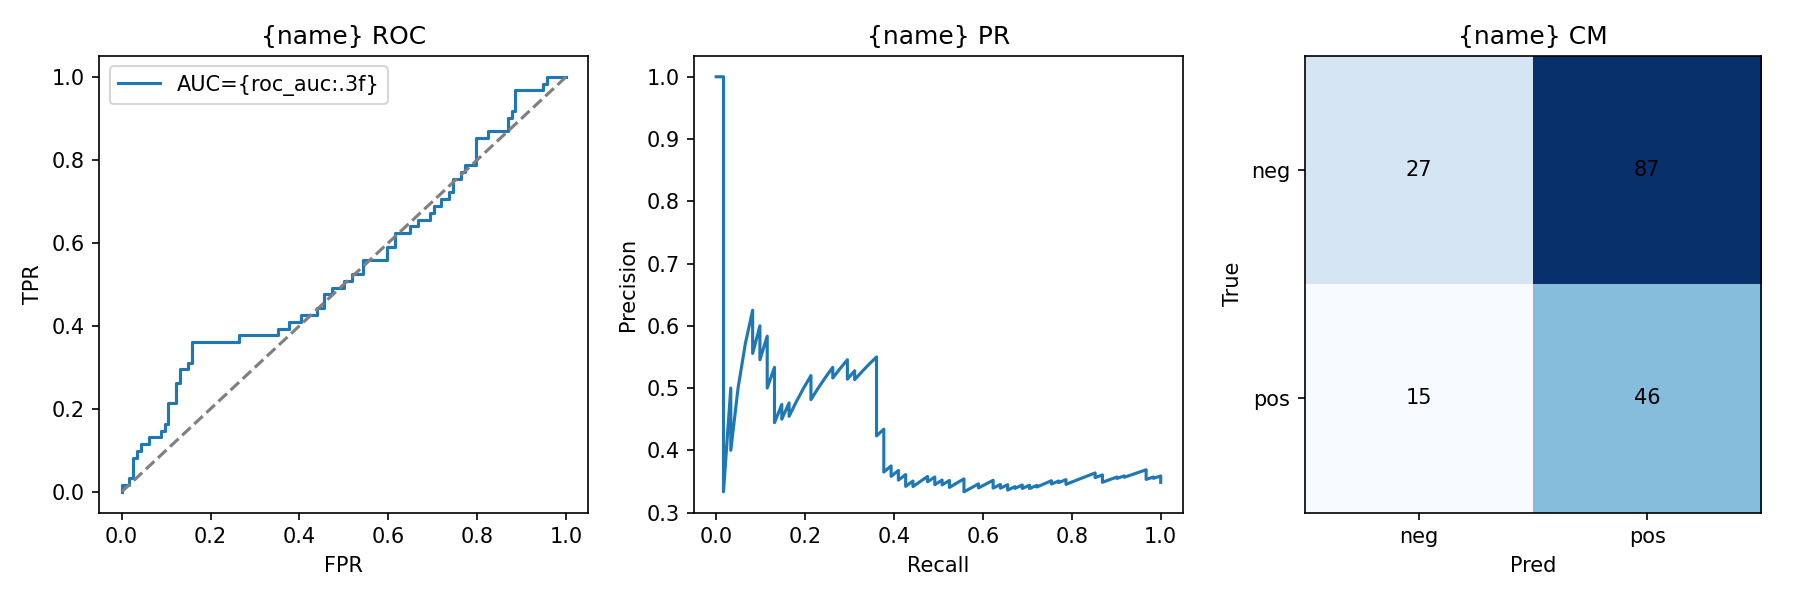

[표시] PoC/v1/_logs_local/test_viz.png


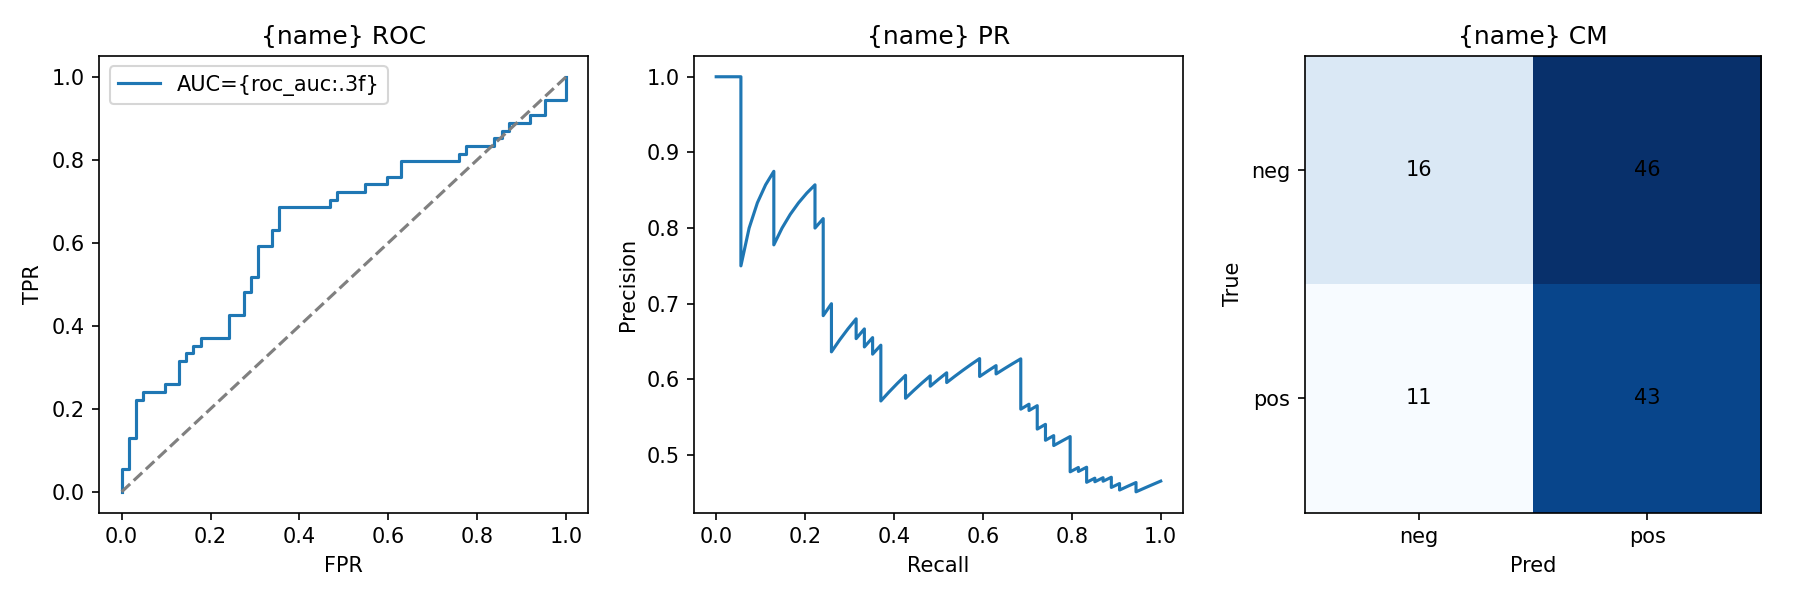

In [9]:
# val/test 예측 CSV로 ROC/PR/Confusion Matrix 생성 후 로컬 표시
viz_tpl = '''
{REMOTE_VENV}/bin/python - <<'PY'
import json, pathlib, subprocess, sys
import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'matplotlib'])
    import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix

log_dir = pathlib.Path('{REMOTE_LOG}')
val_csv = log_dir / 'val_preds.csv'
test_csv = log_dir / 'test_preds.csv'
plt.switch_backend('Agg')

def plot_split(name, csv_path):
    if not csv_path.exists():
        print(f'[{{name}}] CSV 없음:', csv_path)
        return
    df = pd.read_csv(csv_path)
    if df.empty:
        print(f'[{{name}}] CSV 비어있음')
        return
    y = df['label'].values
    p = df['prob'].values
    fpr, tpr, _ = roc_curve(y, p)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y, p)
    cm = confusion_matrix(y, p >= 0.5, labels=[0, 1])

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].plot(fpr, tpr, label=f'AUC={{roc_auc:.3f}}')
    axs[0].plot([0, 1], [0, 1], '--', color='gray')
    axs[0].set_title(f'{{name}} ROC')
    axs[0].legend()
    axs[0].set_xlabel('FPR'); axs[0].set_ylabel('TPR')

    axs[1].plot(rec, prec)
    axs[1].set_title(f'{{name}} PR')
    axs[1].set_xlabel('Recall'); axs[1].set_ylabel('Precision')

    cm = cm.astype(int)
    axs[2].imshow(cm, cmap='Blues')
    axs[2].set_xticks([0, 1]); axs[2].set_yticks([0, 1])
    axs[2].set_xticklabels(['neg', 'pos']); axs[2].set_yticklabels(['neg', 'pos'])
    axs[2].set_xlabel('Pred'); axs[2].set_ylabel('True')
    axs[2].set_title(f'{{name}} CM')
    for (i, j), v in np.ndenumerate(cm):
        axs[2].text(j, i, int(v), ha='center', va='center')
    fig.tight_layout()
    out = log_dir / f"{name.lower()}_viz.png"
    fig.savefig(out, dpi=150)
    plt.close(fig)
    print(f'[{{name}}] 저장:', out)

plot_split('val', val_csv)
plot_split('test', test_csv)
PY
'''
viz_cmd = viz_tpl.replace('{REMOTE_VENV}', REMOTE_VENV).replace('{REMOTE_LOG}', REMOTE_LOG)
print('[단계] 원격 성능 시각화 명령:')
print(viz_cmd)
run_ssh(viz_cmd)

# 로컬로 PNG 내려받아 노트북에 표시
from pathlib import Path
from IPython.display import Image, display
local_dir = Path('PoC/v1/_logs_local')
local_dir.mkdir(parents=True, exist_ok=True)

for name in ['val_viz.png','test_viz.png']:
    remote_path = f"{REMOTE_LOG}/{name}"
    try:
        rsync_download(remote_path, local_dir)
    except Exception as e:
        print(f'[경고] {name} 다운로드 실패:', e)

for name in ['val_viz.png','test_viz.png']:
    lp = local_dir / name
    if lp.exists():
        print(f'[표시] {lp}')
        display(Image(filename=str(lp)))
    else:
        print(f'[경고] {lp} 없음')


## 8.5 SVS 샘플 업로드 (최대 5개)
- 로컬 `/Volumes/Expansion/2023/<케이스>/...svs`에서 최대 5개만 선택해 RunPod `REMOTE_RAW`로 업로드합니다.
- `SAMPLE_SVS`에 구체 경로를 적지 않으면 폴더 순서대로 5개 자동 선택합니다.


In [51]:

from pathlib import Path
import subprocess, io
import pandas as pd

LOCAL_SVS_ROOT = Path('/Volumes/Expansion/2023')
SAMPLE_SVS_LIMIT = 5
# 직접 지정 시 이 리스트가 우선. 비우면 manifest의 test split 기준 자동 선택
SAMPLE_SVS = []


def _remote_manifest_df():
    parts = _ssh_parts(
        SSH_HOST_DIRECT if USE_DIRECT_FOR_SSH else SSH_HOST_GATEWAY,
        SSH_PORT_DIRECT if USE_DIRECT_FOR_SSH else None,
    )
    proc = subprocess.run(parts + [f"cat {REMOTE_MANIFEST}"], capture_output=True, text=True)
    if proc.returncode != 0 or not proc.stdout.strip():
        raise SystemExit(f"[오류] manifest를 읽지 못함: {proc.stderr[:200]}")
    return pd.read_csv(io.StringIO(proc.stdout))


def _find_local_svs(root: Path, slide_id: str):
    bases = [slide_id]
    if '#' in slide_id:
        bases.append(slide_id.split('#')[0])
    bases.append(Path(slide_id).stem)
    bases = list(dict.fromkeys([b for b in bases if b]))
    for base in bases:
        for pat in [f"**/{base}.svs", f"**/{base}*.svs"]:
            hits = sorted(root.glob(pat))
            if hits:
                return hits[0]
    return None


def pick_svs(root: Path, slide_ids, limit=5):
    picked, missing = [], []
    for sid in slide_ids:
        hit = _find_local_svs(root, sid)
        if hit:
            picked.append(hit)
        else:
            missing.append(sid)
        if len(picked) >= limit:
            break
    return picked[:limit], missing

if SAMPLE_SVS:
    svs_list = [Path(p) for p in SAMPLE_SVS]
    missing_local = []
else:
    df = _remote_manifest_df()
    if 'split' not in df.columns:
        raise SystemExit("manifest에 split 컬럼이 없습니다.")
    test_df = df[df['split'] == 'test']
    if test_df.empty:
        raise SystemExit("test split이 비어 있습니다. manifest 생성 단계를 다시 확인하세요.")
    if 'slide_id' in test_df.columns:
        slide_ids = test_df['slide_id'].astype(str).unique().tolist()
    elif 'slide' in test_df.columns:
        slide_ids = test_df['slide'].astype(str).unique().tolist()
    else:
        slide_ids = test_df['pt_path'].apply(lambda p: Path(p).stem).unique().tolist()
    svs_list, missing_local = pick_svs(LOCAL_SVS_ROOT, slide_ids, SAMPLE_SVS_LIMIT)

if missing_local:
    print('[경고] 로컬에서 못 찾은 test slide_id:', missing_local)
if not svs_list:
    raise SystemExit("로컬에서 test split에 해당하는 SVS를 찾지 못했습니다. LOCAL_SVS_ROOT/slide_id 매칭을 확인하세요.")

print('[업로드 대상]', len(svs_list))
for p in svs_list:
    print(' -', p)
    rsync_upload(p, REMOTE_RAW)
print('[완료] 업로드 후 원격 RAW 경로:', REMOTE_RAW)


[업로드 대상] 5
 - /Volumes/Expansion/2023/S23-03088/S23-03088#1###3.svs
[local] $ rsync -avh --no-perms --no-owner --no-group --partial --progress -e 'ssh -i /Users/curv/.ssh/runpod_peter -p 22027' '/Volumes/Expansion/2023/S23-03088/S23-03088#1###3.svs' root@69.30.85.100:/workspace/data/raw/
Transfer starting: 1 files

sent 57 bytes  received 20 bytes  186 bytes/sec
total size is 442M  speedup is 5743292.54

 - /Volumes/Expansion/2023/S23-07102/S23-07102#1###2.svs
[local] $ rsync -avh --no-perms --no-owner --no-group --partial --progress -e 'ssh -i /Users/curv/.ssh/runpod_peter -p 22027' '/Volumes/Expansion/2023/S23-07102/S23-07102#1###2.svs' root@69.30.85.100:/workspace/data/raw/
Transfer starting: 1 files

sent 57 bytes  received 20 bytes  166 bytes/sec
total size is 1091M  speedup is 14175017.64

 - /Volumes/Expansion/2023/S23-06617/S23-06617#1###0.svs
[local] $ rsync -avh --no-perms --no-owner --no-group --partial --progress -e 'ssh -i /Users/curv/.ssh/runpod_peter -p 22027' '/Volumes/

## 9. 히트맵 생성 (MIL 학습 결과)
- 훈련된 MIL 체크포인트(`best.pt`)로 각 test slide의 타일 attention을 추출해 히트맵을 만듭니다.
- manifest의 split=test를 자동 선택하며, RAW 디렉터리에 실제 파일이 있는 slide만 처리합니다.
- 출력은 `REMOTE_HEATMAP`에 `<slide_id>_mil_heatmap.png`로 저장된 후 로컬 `PoC/v1/output/heatmaps`로 동기화됩니다.


In [57]:

# MIL 히트맵 파라미터
HEATMAP_SPLIT = 'test'
HEATMAP_MAX_SLIDES = 5  # 생성할 slide 최대 개수 (None이면 전체 split)
HEATMAP_MAX_THUMB = 2048  # 썸네일 최대 길이(px)
HEATMAP_SMOOTH_SIGMA = 8
HEATMAP_ALPHA = 0.45
HEATMAP_TILE_SIZE_FALLBACK = 1024  # pt에 tile_size_scaled 없을 때 level-0 tile 크기 기본값

print('HEATMAP_SPLIT:', HEATMAP_SPLIT)
print('히트맵 출력 원격 경로:', REMOTE_HEATMAP)


HEATMAP_REMOTE_SVS: (auto pick from REMOTE_RAW)
HF token: set


In [59]:

# RunPod에서 MIL 결과 기반 히트맵 생성
import textwrap, json, subprocess, shlex
from string import Template

tpl = Template(textwrap.dedent('''
$REMOTE_VENV/bin/python - <<'PY'
import os, json
import torch
import pandas as pd
import numpy as np
from pathlib import Path
import importlib.util
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from PIL import Image
import openslide

MANIFEST = Path('$REMOTE_MANIFEST')
CKPT = Path('$REMOTE_CHECKPOINT') / 'best.pt'
RAW_DIR = Path('$REMOTE_RAW')
OUT_DIR = Path('$REMOTE_HEATMAP')
SPLIT = '$HEATMAP_SPLIT'
MAX_SLIDES = $HEATMAP_MAX_SLIDES
MAX_THUMB = $HEATMAP_MAX_THUMB
SMOOTH = $HEATMAP_SMOOTH_SIGMA
ALPHA = $HEATMAP_ALPHA
FALLBACK_TILE = $HEATMAP_TILE_SIZE_FALLBACK

spec = importlib.util.spec_from_file_location('train_mil', '$REMOTE_TRAIN_SCRIPT')
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
AttentionMIL, TransMIL = mod.AttentionMIL, mod.TransMIL
load_feats_coords = mod.load_feats_coords
infer_in_dim = mod.infer_in_dim


def load_model(device):
    if not CKPT.exists():
        raise SystemExit(f'checkpoint missing: {CKPT}')
    ck = torch.load(CKPT, map_location=device)
    cfg = ck.get('config', {})
    class Cfg: pass
    args = Cfg()
    for k, v in cfg.items():
        setattr(args, k, v)
    in_dim = infer_in_dim(MANIFEST)
    model_name = getattr(args, 'model', 'abmil')
    if model_name == 'transmil':
        model = TransMIL(
            in_dim,
            depth=getattr(args, 'depth', 2),
            heads=getattr(args, 'heads', 4),
            ff_dim=getattr(args, 'ffn_dim', 512),
            dropout=getattr(args, 'dropout', 0.2),
            use_pos_enc=getattr(args, 'use_pos_enc', False),
        )
    elif model_name == 'clam':
        model = AttentionMIL(in_dim, hidden_dim=getattr(args, 'hidden_dim', 256), dropout=getattr(args, 'dropout', 0.2), gated=True)
    else:
        model = AttentionMIL(in_dim, hidden_dim=getattr(args, 'hidden_dim', 256), dropout=getattr(args, 'dropout', 0.2), gated=False)
    model.load_state_dict(ck['model_state'])
    model.to(device).eval()
    return model


def match_raw(slide_id):
    keys = [slide_id]
    if '#' in slide_id:
        keys.append(slide_id.split('#')[0])
    keys.append(Path(slide_id).stem)
    keys = [k for k in keys if k]
    for p in RAW_DIR.iterdir():
        name = p.name
        if any(k in name for k in keys):
            return p
    return None


def make_thumbnail(slide, max_size=2048):
    w, h = slide.level_dimensions[0]
    scale = max(w, h) / max_size
    thumb = slide.get_thumbnail((int(w/scale), int(h/scale))).convert('RGB')
    return thumb, scale


def render_heatmap(raw_path, coords, scores, tile_size, out_path):
    slide = openslide.OpenSlide(str(raw_path))
    thumb, scale = make_thumbnail(slide, MAX_THUMB)
    tile = int(tile_size)
    thumb_np = np.array(thumb)
    heat = np.zeros((thumb_np.shape[0], thumb_np.shape[1]), dtype=np.float32)
    cnt = np.zeros_like(heat)
    for (x, y), s in zip(coords, scores):
        x0 = int(x / scale)
        y0 = int(y / scale)
        x1 = int((x + tile) / scale)
        y1 = int((y + tile) / scale)
        heat[y0:y1, x0:x1] += s
        cnt[y0:y1, x0:x1] += 1
    mask = cnt > 0
    if mask.any():
        heat[mask] /= cnt[mask]
    heat = gaussian_filter(heat, sigma=SMOOTH)
    if mask.any():
        p2, p98 = np.percentile(heat[mask], [2, 98])
    else:
        p2, p98 = float(heat.min()), float(heat.max())
    heat = np.clip((heat - p2) / (p98 - p2 + 1e-6), 0, 1)
    cmap = plt.get_cmap('turbo')
    heat_rgb = (cmap(heat)[:, :, :3] * 255).astype(np.uint8)
    overlay = (ALPHA * heat_rgb + (1 - ALPHA) * thumb_np).astype(np.uint8)
    Image.fromarray(overlay).save(out_path)


def main():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    if device != 'cuda':
        raise SystemExit('CUDA device not available on RunPod')
    if not MANIFEST.exists():
        raise SystemExit(f'manifest missing: {MANIFEST}')
    df = pd.read_csv(MANIFEST)
    df = df[df['split'] == SPLIT]
    if df.empty:
        raise SystemExit(f'split {SPLIT} is empty')
    if MAX_SLIDES:
        df = df.head(MAX_SLIDES)
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    model = load_model(device)
    processed = []
    for _, row in df.iterrows():
        slide_id = str(row['slide_id'])
        pt_path = Path(row['pt_path'])
        if not pt_path.exists():
            print('[skip] pt missing', pt_path)
            continue
        raw = match_raw(slide_id)
        if raw is None:
            print('[skip] RAW not found for', slide_id)
            continue
        data = torch.load(pt_path, map_location='cpu')
        feats, coords = load_feats_coords(data)
        if coords is None:
            print('[skip] coords missing', pt_path)
            continue
        coords_np = coords.cpu().numpy()
        tile_size = data.get('tile_size_scaled') or int(FALLBACK_TILE)
        with torch.inference_mode():
            feats_t = feats.to(device)
            coords_t = coords.to(device)
            logit, attn = model(feats_t, coords_t)
            prob = torch.sigmoid(logit).item()
            scores = attn.detach().cpu().numpy().astype(np.float32)
        out_path = OUT_DIR / f"{slide_id}_mil_heatmap.png"
        render_heatmap(raw, coords_np, scores, tile_size, out_path)
        processed.append({'slide_id': slide_id, 'prob': prob, 'out': str(out_path)})
        print('[완료] heatmap', slide_id, 'prob', round(prob, 4), '->', out_path)

    print('총 생성:', len(processed))
    if processed:
        print(json.dumps(processed, indent=2))

if __name__ == '__main__':
    main()
PY
'''))

script = tpl.substitute(
    REMOTE_VENV=REMOTE_VENV,
    REMOTE_MANIFEST=REMOTE_MANIFEST,
    REMOTE_CHECKPOINT=REMOTE_CHECKPOINT,
    REMOTE_RAW=REMOTE_RAW,
    REMOTE_HEATMAP=REMOTE_HEATMAP,
    HEATMAP_SPLIT=HEATMAP_SPLIT,
    HEATMAP_MAX_SLIDES=HEATMAP_MAX_SLIDES,
    HEATMAP_MAX_THUMB=HEATMAP_MAX_THUMB,
    HEATMAP_SMOOTH_SIGMA=HEATMAP_SMOOTH_SIGMA,
    HEATMAP_ALPHA=HEATMAP_ALPHA,
    HEATMAP_TILE_SIZE_FALLBACK=HEATMAP_TILE_SIZE_FALLBACK,
    REMOTE_TRAIN_SCRIPT=REMOTE_TRAIN_SCRIPT,
)

print('[ssh] MIL 히트맵 생성 스크립트 실행')
run_ssh(script, check=True)


Traceback (most recent call last):
  File "<stdin>", line 40, in <module>
NameError: name 'limit' is not defined. Did you mean: 'list'?


SystemExit: SVS를 찾을 수 없습니다. HEATMAP_REMOTE_SVS/HEATMAP_REMOTE_SVS_LIST 또는 test split/RAW 매칭을 확인

/Users/curv/.pyenv/versions/3.11.14/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:

# 히트맵 결과를 로컬로 다운로드
local_out = Path('PoC/v1/output/heatmaps')
local_out.mkdir(parents=True, exist_ok=True)
rsync_download(f"{REMOTE_HEATMAP}/", local_out)
print('다운로드 완료 →', local_out)
print('로컬 PNG:', list(local_out.glob('*_heatmap.png'))[:10])
